# Model Comparison — Classical ML vs Quantum ML
## AI-Based Wage Gap Detection in India

This notebook provides a rigorous side-by-side comparison of all models including:
- Full metrics table (Accuracy, Precision, Recall, F1, ROC-AUC)
- Confusion matrices for each model
- Feature importance analysis
- QML vs Classical insight: where does QML add value?
- Error analysis: who does each model get wrong?

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

X_test = pd.read_csv('data/X_test.csv').values
y_test = pd.read_csv('data/y_test.csv').values.ravel()

model_lr  = pickle.load(open('models/logistic_model.pkl', 'rb'))
model_rf  = pickle.load(open('models/random_forest_model.pkl', 'rb'))
model_gb  = pickle.load(open('models/gradient_boosting_model.pkl', 'rb'))
model_ens = pickle.load(open('models/ensemble_model.pkl', 'rb'))
FEATURES  = pickle.load(open('models/feature_names.pkl', 'rb'))

qml_available = os.path.exists('outputs/qml_vs_classical_comparison.csv')
print(f'QML results available: {qml_available}')
print(f'Test set shape: {X_test.shape}')

QML results available: True
Test set shape: (10000, 6)


## Part 1: All Model Metrics (Classical + QML)

In [2]:
models = {
    'Logistic Regression': model_lr,
    'Random Forest'      : model_rf,
    'Gradient Boosting'  : model_gb,
    'Ensemble (LR+RF+GB)': model_ens
}

results       = {}
predictions   = {}
probabilities = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    predictions[name]   = y_pred
    probabilities[name] = y_proba
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T

# Merge QML results into the same table if available
if qml_available:
    qml_comp = pd.read_csv('outputs/qml_vs_classical_comparison.csv', index_col=0)
    # Add any QML rows not already present
    qml_only = qml_comp[~qml_comp.index.isin(results_df.index)]
    all_results = pd.concat([results_df, qml_only[results_df.columns]])
else:
    all_results = results_df

all_results.to_csv('outputs/model_comparison_final.csv')

print('=== All Model Performance (Classical + QML) ===')
print(all_results.round(4).to_string())


=== All Model Performance (Classical + QML) ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9509     0.9548  0.9766  0.9656   0.9903
Random Forest          0.9924     0.9920  0.9973  0.9946   0.9997
Gradient Boosting      0.9997     0.9999  0.9997  0.9998   0.9999
Ensemble (LR+RF+GB)    0.9957     0.9955  0.9984  0.9970   0.9998
Ensemble               0.9957     0.9955  0.9984  0.9970   0.9998
QML (VQC)              0.8448     0.8292  0.9824  0.8993      NaN


## Part 2: Confusion Matrices

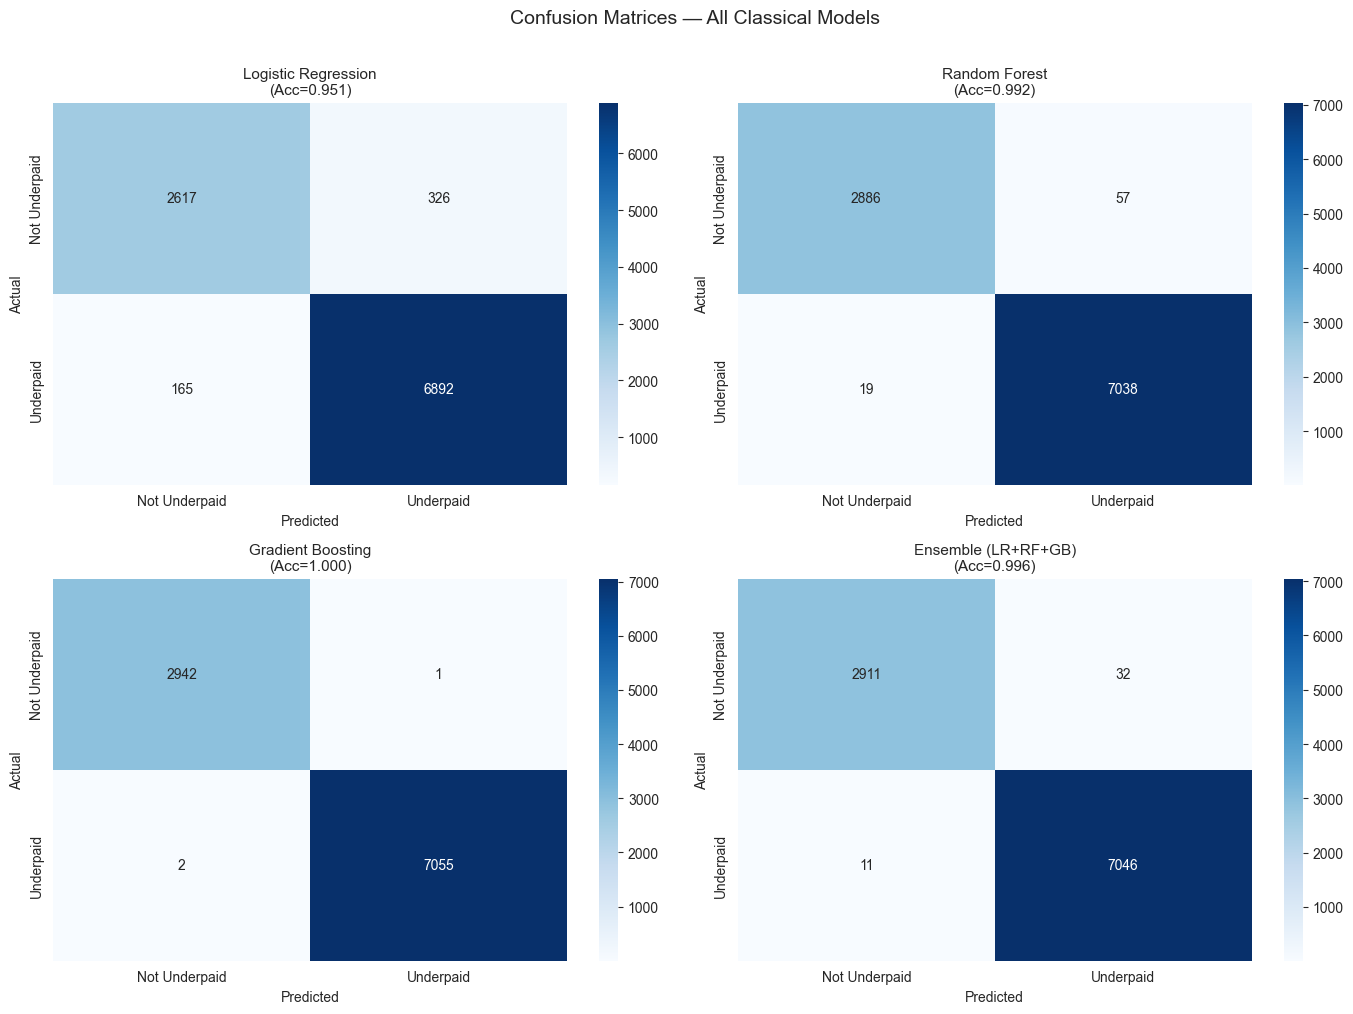

Saved: outputs/confusion_matrices.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Underpaid', 'Underpaid'],
                yticklabels=['Not Underpaid', 'Underpaid'])
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\n(Acc={acc:.3f})', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Classical Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/confusion_matrices.png')

## Part 3: ROC Curves

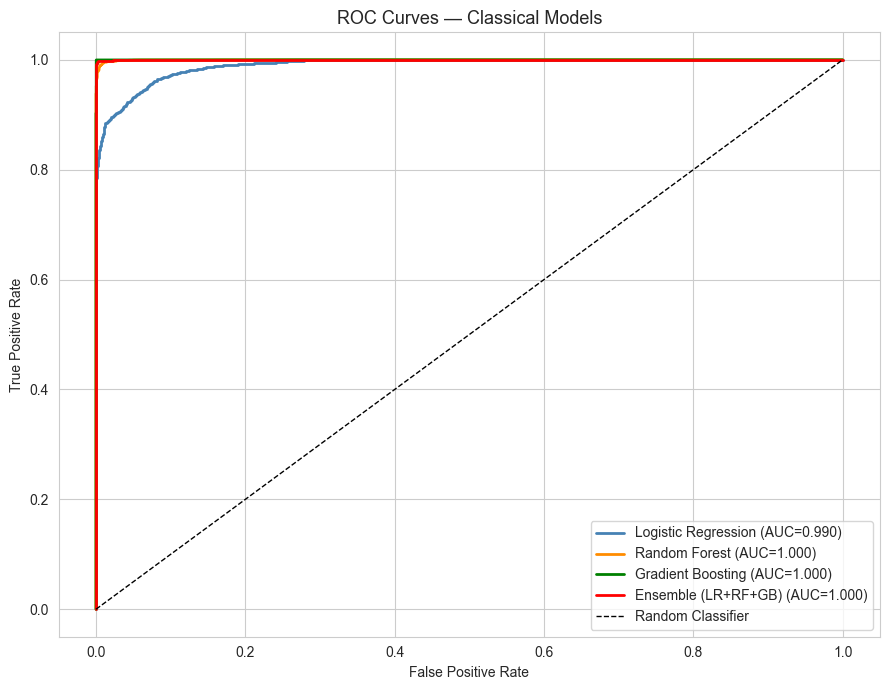

Saved: outputs/roc_curves.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['steelblue', 'darkorange', 'green', 'red']

for (name, y_proba), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_title('ROC Curves — Classical Models', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=120)
plt.show()
print('Saved: outputs/roc_curves.png')

## Part 4: Feature Importance Deep Dive

=== Feature Importance Rankings ===
    Feature  Random Forest  Grad Boosting  Average
Actual Wage         0.7243         0.9167   0.8205
      State         0.0902         0.0832   0.0867
  Education         0.1175         0.0000   0.0587
   Industry         0.0337         0.0000   0.0168
 Experience         0.0248         0.0000   0.0124
     Gender         0.0096         0.0000   0.0048


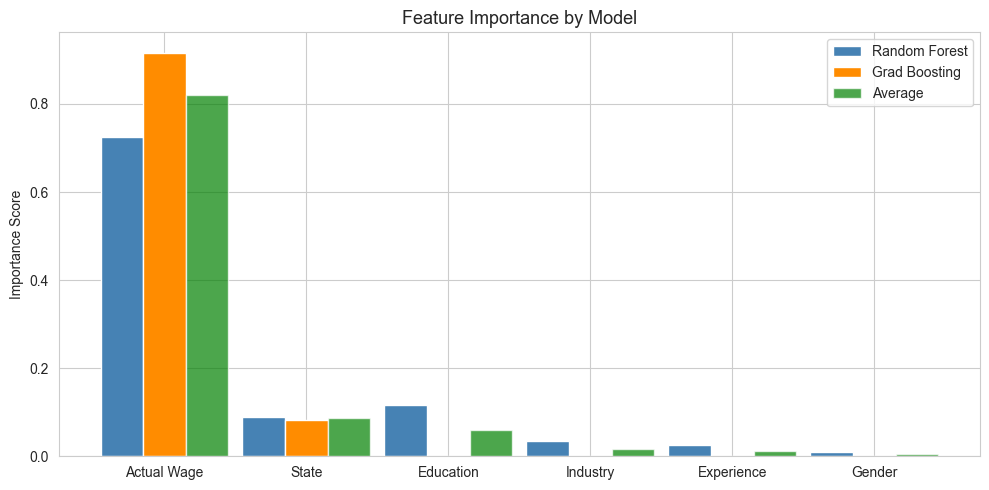


Key Insight: Actual Wage dominates classical models.
QML can detect subtler patterns via quantum entanglement between features.


In [5]:
feature_labels = ['Gender', 'Education', 'Experience', 'Actual Wage', 'State', 'Industry']

imp_rf  = model_rf.feature_importances_
imp_gb  = model_gb.feature_importances_
imp_avg = (imp_rf + imp_gb) / 2

imp_df = pd.DataFrame({
    'Feature'      : feature_labels,
    'Random Forest': imp_rf,
    'Grad Boosting': imp_gb,
    'Average'      : imp_avg
}).sort_values('Average', ascending=False)

print('=== Feature Importance Rankings ===')
print(imp_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(feature_labels))
w     = 0.3
order = imp_df['Feature'].tolist()

rf_vals  = [imp_df[imp_df['Feature'] == f]['Random Forest'].values[0] for f in order]
gb_vals  = [imp_df[imp_df['Feature'] == f]['Grad Boosting'].values[0] for f in order]
avg_vals = [imp_df[imp_df['Feature'] == f]['Average'].values[0] for f in order]

ax.bar(x - w, rf_vals,  width=w, label='Random Forest', color='steelblue')
ax.bar(x,     gb_vals,  width=w, label='Grad Boosting', color='darkorange')
ax.bar(x + w, avg_vals, width=w, label='Average',       color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title('Feature Importance by Model', fontsize=13)
ax.set_ylabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/feature_importance_comparison.png', dpi=120)
plt.show()

print('\nKey Insight: Actual Wage dominates classical models.')
print('QML can detect subtler patterns via quantum entanglement between features.')

## Part 5: Error Analysis — Where Do Models Fail?

c:\Users\rasgu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Gradient Boosting errors: 3 / 10,000 (0.0%)

=== Error Breakdown by Gender ===
               predicted
gender actual           
Male   0               1
       1               2

=== Top Industries in Errors ===
industry
Food Processing    1
Leather            1
Machinery          1
Name: count, dtype: int64

=== Top Education Levels in Errors ===
education_level
10th Pass    2
12th Pass    1
Name: count, dtype: int64


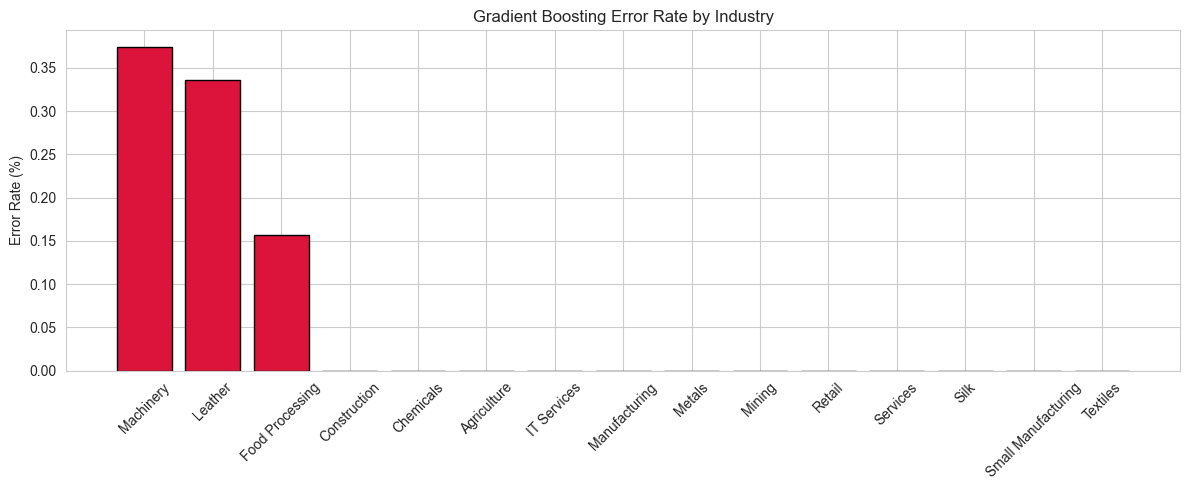

Saved: outputs/error_analysis_by_industry.png


In [6]:
df = pd.read_csv('data/wage_gap_data.csv')

le_gender    = pickle.load(open('models/le_gender.pkl',    'rb'))
le_education = pickle.load(open('models/le_education.pkl', 'rb'))
le_state     = pickle.load(open('models/le_state.pkl',     'rb'))
le_industry  = pickle.load(open('models/le_industry.pkl',  'rb'))
scaler       = pickle.load(open('models/scaler.pkl',       'rb'))

df['gender_enc']    = le_gender.transform(df['gender'])
df['education_enc'] = le_education.transform(df['education_level'])
df['state_enc']     = le_state.transform(df['state'])
df['industry_enc']  = le_industry.transform(df['industry'])

X_all = scaler.transform(df[FEATURES].values)
y_all = df['is_underpaid'].values

_, X_te, _, y_te_raw, idx_tr, idx_te = train_test_split(
    X_all, y_all, df.index,
    test_size=0.2, random_state=42, stratify=y_all
)
df_test = df.loc[idx_te].copy().reset_index(drop=True)

y_pred_best      = model_gb.predict(X_te)
df_test['predicted'] = y_pred_best
df_test['actual']    = y_te_raw
df_test['correct']   = (df_test['predicted'] == df_test['actual'])

errors = df_test[~df_test['correct']]
print(f'Gradient Boosting errors: {len(errors):,} / {len(df_test):,} '
      f'({len(errors)/len(df_test)*100:.1f}%)')
print('\n=== Error Breakdown by Gender ===')
print(errors.groupby(['gender','actual'])[['predicted']].count())
print('\n=== Top Industries in Errors ===')
print(errors['industry'].value_counts().head(7))
print('\n=== Top Education Levels in Errors ===')
print(errors['education_level'].value_counts().head(5))

# Visualise error rate by industry
err_by_ind = (
    df_test.groupby('industry')['correct']
    .apply(lambda x: (~x).mean() * 100)
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(err_by_ind.index, err_by_ind.values, color='crimson', edgecolor='black')
ax.set_title('Gradient Boosting Error Rate by Industry', fontsize=12)
ax.set_ylabel('Error Rate (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outputs/error_analysis_by_industry.png', dpi=120)
plt.show()
print('Saved: outputs/error_analysis_by_industry.png')


## Part 6: Final Summary Scorecard

In [7]:
print('=' * 70)
print('FINAL MODEL SCORECARD — ALL MODELS')
print('=' * 70)
print(all_results.round(4).to_string())

best_name = all_results['F1'].idxmax()
print(f'\n-> Best Model : {best_name}')
print(f'   F1 Score   : {all_results.loc[best_name, "F1"]:.4f}')
if 'ROC-AUC' in all_results.columns and not pd.isna(all_results.loc[best_name, 'ROC-AUC']):
    print(f'   ROC-AUC    : {all_results.loc[best_name, "ROC-AUC"]:.4f}')
print('\nComparison saved to outputs/model_comparison_final.csv')


FINAL MODEL SCORECARD — ALL MODELS
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9509     0.9548  0.9766  0.9656   0.9903
Random Forest          0.9924     0.9920  0.9973  0.9946   0.9997
Gradient Boosting      0.9997     0.9999  0.9997  0.9998   0.9999
Ensemble (LR+RF+GB)    0.9957     0.9955  0.9984  0.9970   0.9998
Ensemble               0.9957     0.9955  0.9984  0.9970   0.9998
QML (VQC)              0.8448     0.8292  0.9824  0.8993      NaN

-> Best Model : Gradient Boosting
   F1 Score   : 0.9998
   ROC-AUC    : 0.9999

Comparison saved to outputs/model_comparison_final.csv
